Coronavirus outbreak started in Wuhan, China and has been spreading around the globe. 
Below data shows some analysis of affected cases for Novel Coronavirus around the world.
I have gathered the data from Johns Hopkins University and referred to the dashboard they have created displaying the affected cases.

Originally, I wanted to calculate the growth rate of confirmed cases in each region, but I could not figure out how to subtract the previous row of data and place them on the correct date. (other than using an excel)

In the future, I would like to explore the data through visualizing it on a geographical map so data is more interactive and engaging.

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load in 

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the "../input/" directory.
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# Any results you write to the current directory are saved as output.

/kaggle/input/corona19/0215.csv
/kaggle/input/corona19/0224.csv
/kaggle/input/corona19/0124.csv
/kaggle/input/corona19/0201.csv
/kaggle/input/corona19/0220.csv
/kaggle/input/corona19/0212.csv
/kaggle/input/corona19/0202.csv
/kaggle/input/corona19/0210.csv
/kaggle/input/corona19/0128.csv
/kaggle/input/corona19/0129.csv
/kaggle/input/corona19/time_series_19-covid-Deaths.csv
/kaggle/input/corona19/0217.csv
/kaggle/input/corona19/0221.csv
/kaggle/input/corona19/corona_total.csv
/kaggle/input/corona19/0208.csv
/kaggle/input/corona19/0130.csv
/kaggle/input/corona19/time_series_19-covid-Confirmed.csv
/kaggle/input/corona19/0225.csv
/kaggle/input/corona19/0206.csv
/kaggle/input/corona19/0219.csv
/kaggle/input/corona19/0209.csv
/kaggle/input/corona19/0218.csv
/kaggle/input/corona19/0207.csv
/kaggle/input/corona19/0222.csv
/kaggle/input/corona19/0123.csv
/kaggle/input/corona19/0126.csv
/kaggle/input/corona19/0203.csv
/kaggle/input/corona19/0122.csv
/kaggle/input/corona19/0127.csv
/kaggle/input/c

In [2]:
import pandas_datareader.data as web
import matplotlib.pyplot as plt
import datetime as dt

In [3]:
#data_0225 contains latest count of confirmed/deaths/recovered count of Corona virus for each province/state
data_0225=pd.read_csv("../input/corona19/0225.csv")
data_0225.head()

,Province/State,Country/Region,Last Update,Confirmed,Deaths,Recovered
0,Hubei,Mainland China,2/25/2020,64786,2563,18971
1,Guangdong,Mainland China,2/25/2020,1347,7,822
2,Henan,Mainland China,2/25/2020,1271,19,1002
3,Zhejiang,Mainland China,2/25/2020,1205,1,808
4,Hunan,Mainland China,2/25/2020,1016,4,768


In [4]:
#data_total contains total confirmed/deaths/recovered cases for Corona virus for each day from its first outbreak date to Feb. 25
#this is what original data looks like
data_total=pd.read_csv("/kaggle/input/corona19/corona_compiled.csv")
data_total.head()

,Country/Region,Province/State,Confirmed,Deaths,Recovered,Date,Last Update
0,China,Anhui,1.0,NaN,NaN,1/22/2020,1/22/2020
1,China,Beijing,14.0,NaN,NaN,1/22/2020,1/22/2020
2,China,Chongqing,6.0,NaN,NaN,1/22/2020,1/22/2020
3,China,Fujian,1.0,NaN,NaN,1/22/2020,1/22/2020
4,China,Gansu,NaN,NaN,NaN,1/22/2020,1/22/2020


In [5]:
#showing current data type for each column
data_total.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2379 entries, 0 to 2378
Data columns (total 7 columns):
Country/Region    2379 non-null object
Province/State    1718 non-null object
Confirmed         2360 non-null float64
Deaths            1938 non-null float64
Recovered         1991 non-null float64
Date              2379 non-null object
Last Update       2379 non-null object
dtypes: float64(3), object(4)
memory usage: 130.2+ KB


In [6]:
#convert NaN values to "0"
df = data_total.fillna(0)

#convert strings to date type for necessary columns
df[['Date']] = pd.to_datetime(df['Date'])
df[['Last Update']] = pd.to_datetime(df['Last Update'])

df.head()

,Country/Region,Province/State,Confirmed,Deaths,Recovered,Date,Last Update
0,China,Anhui,1.0,0.0,0.0,2020-01-22,2020-01-22
1,China,Beijing,14.0,0.0,0.0,2020-01-22,2020-01-22
2,China,Chongqing,6.0,0.0,0.0,2020-01-22,2020-01-22
3,China,Fujian,1.0,0.0,0.0,2020-01-22,2020-01-22
4,China,Gansu,0.0,0.0,0.0,2020-01-22,2020-01-22


World Trends

In [7]:
#here is an world's accumulative daily status table for Coronavirus outbreak
daily_cases = df.groupby("Date", as_index=False)["Confirmed", "Deaths", "Recovered"].sum().set_index("Date")
daily_cases

,Confirmed,Deaths,Recovered
Date,,,
2020-01-22,555.0,17.0,28.0
2020-01-23,653.0,18.0,30.0
2020-01-24,941.0,26.0,36.0
2020-01-25,1438.0,42.0,39.0
2020-01-26,2118.0,56.0,52.0
2020-01-27,2927.0,82.0,61.0
2020-01-28,5578.0,131.0,107.0
2020-01-29,6165.0,133.0,126.0
2020-01-30,8235.0,171.0,143.0


In [8]:
#Following table shows world total coronavirus cases as of 2/25/2020
confirmed = data_0225['Confirmed'].sum()
death = data_0225['Deaths'].sum()
recovered = data_0225['Recovered'].sum()

df = pd.DataFrame({"World Total": [confirmed, death, recovered]})
df.rename(index = {0: "Confirmed", 1: "Death", 2: "Recovered"}).T

,Confirmed,Death,Recovered
World Total,80415,2708,27905


Text(0.5, 1.0, 'Accumulated COVID-19 Case Trend Over Time')

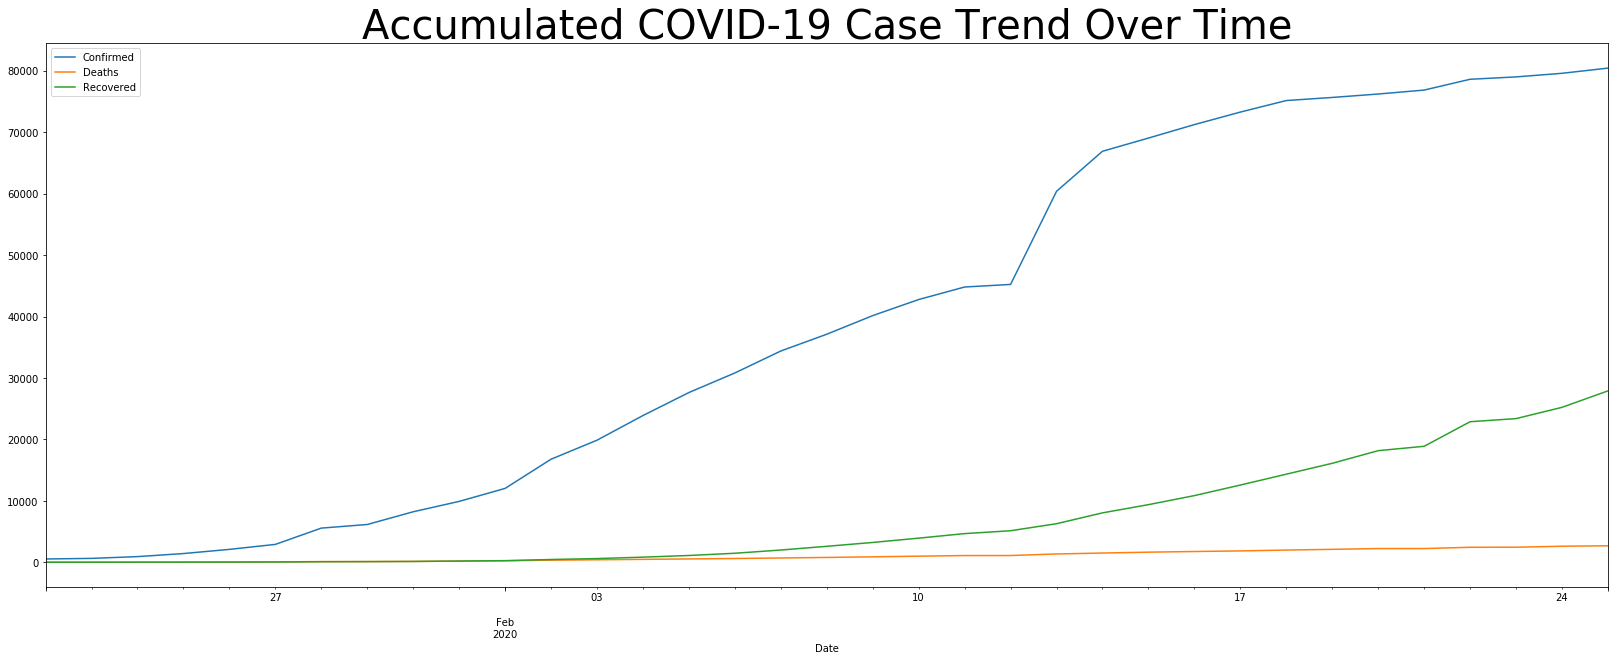

In [9]:
#Line graph displaying the trend for confirmed, deaths, recovered cases of Coronavirus worldwide.
daily_cases.plot(kind='line', figsize=(28,10))
plt.title('Accumulated COVID-19 Case Trend Over Time', size = 40)


Coronavirus Trend by Country

In [10]:
#Table that shows accumulated Coronavirus status per each country as of 2/25/2020. It is sorted by most to least confirmed cases.

country_cases = data_0225.groupby("Country/Region", as_index=False)["Confirmed", "Deaths", "Recovered"].sum().set_index("Country/Region")
country_cases.sort_values(by=['Confirmed'], ascending=False)

,Confirmed,Deaths,Recovered
Country/Region,,,
Mainland China,77660,2663,27650
South Korea,977,10,22
Others,691,3,0
Italy,322,10,1
Japan,170,1,22
Iran,95,16,0
Singapore,91,0,53
Hong Kong,84,2,19
US,53,0,6


Text(0.5, 1.0, 'Total COVID-19 Cases per Country')

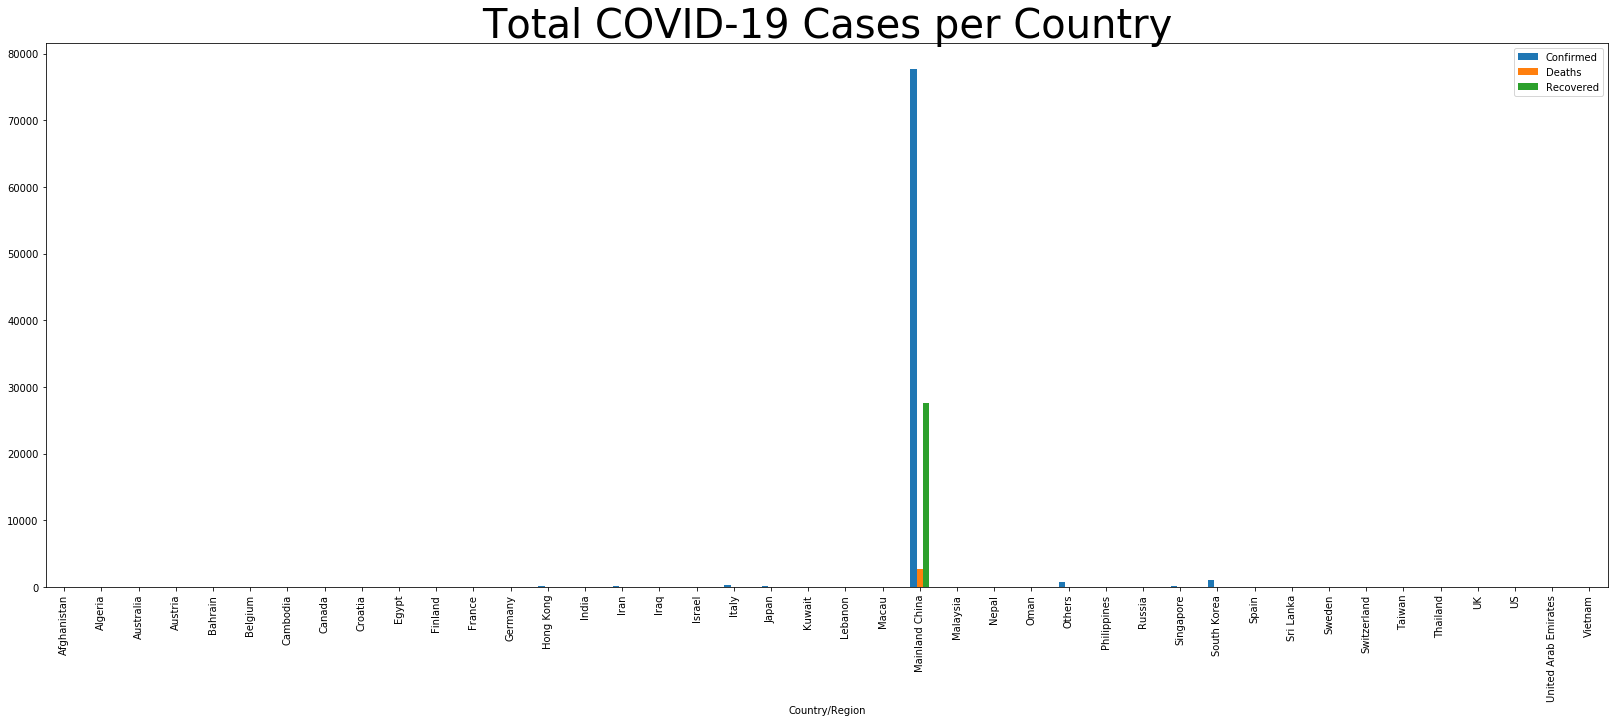

In [11]:
#Bar graph displaying the trend for confirmed, deaths, recovered cases of Coronavirus worldwide per each country.
country_cases.plot(kind='bar', figsize=(28,10))
plt.title('Total COVID-19 Cases per Country', size = 40)

In [12]:
#Because China outnumbers other countries, I've decided to exclude China from the dataset to have clearer visualization for other countries
nonchina_cases = country_cases.drop('Mainland China', axis =0)
nonchina_cases.sort_values(by='Confirmed', ascending = False)

,Confirmed,Deaths,Recovered
Country/Region,,,
South Korea,977,10,22
Others,691,3,0
Italy,322,10,1
Japan,170,1,22
Iran,95,16,0
Singapore,91,0,53
Hong Kong,84,2,19
US,53,0,6
Thailand,37,0,22


Text(0.5, 1.0, 'Number of Confirmed Cases')

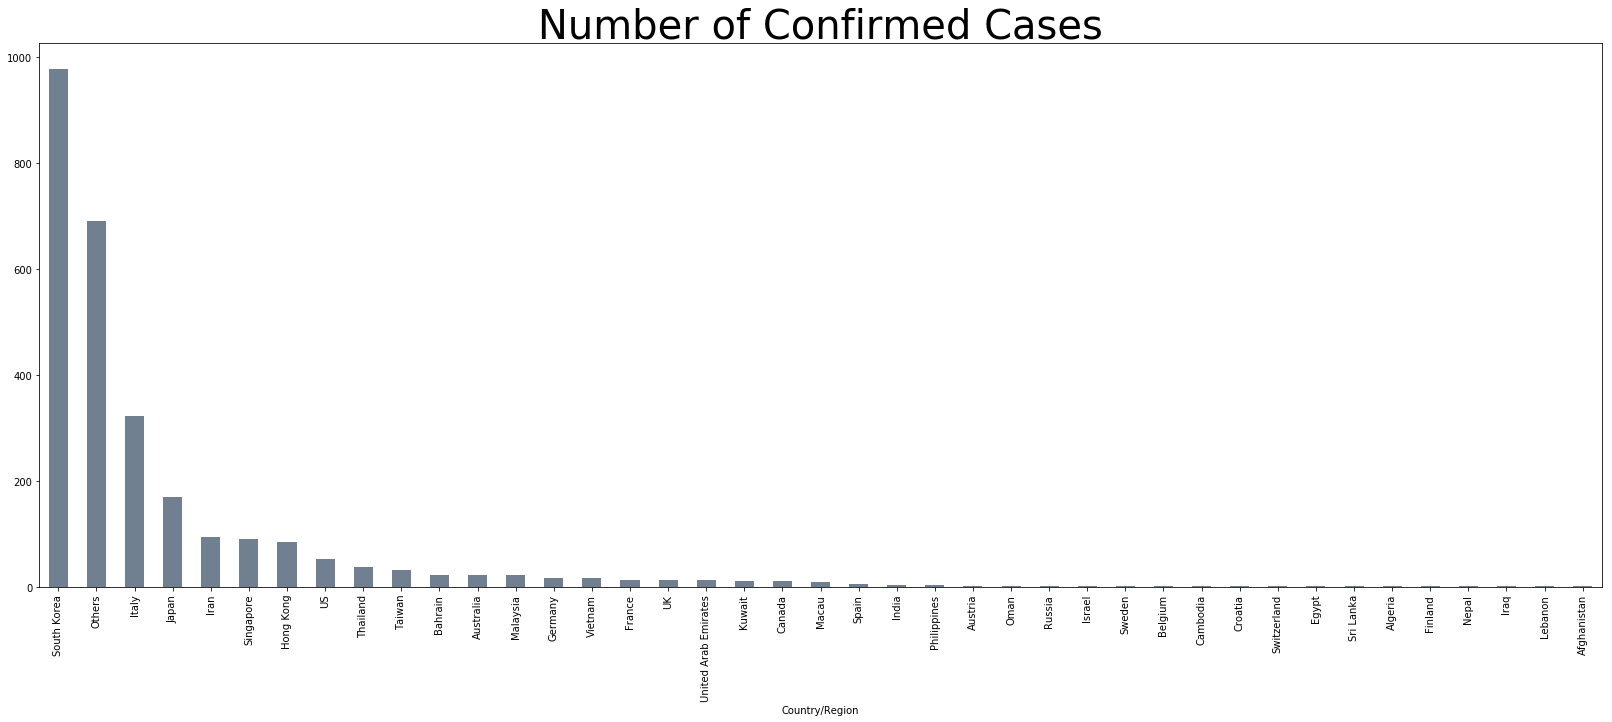

In [13]:
#bar graph displaying the accumulated confirmed cases for Coronavirus per country withouth China
nonchina_confirmed = nonchina_cases.sort_values(by=['Confirmed'], ascending = False).Confirmed
nonchina_confirmed.plot(kind='bar', figsize=(28,10), color = "SlateGray")
plt.title('Number of Confirmed Cases', size = 40)

In [14]:
nonchina.deaths = nonchina_cases.sort_values(by=['Deaths'], ascending = False).Deaths
nonchina.deaths.plot(kind='bar', figsize=(28,10), color = 'DarkRed')
plt.title('Number of Death Cases', size = 40)

NameError: name 'nonchina' is not defined

In [15]:
nonchina.recovered = nonchina_cases.sort_values(by=['Recovered'], ascending = False).Recovered
nonchina.recovered.plot(kind='bar', figsize=(28,10), color = "DarkGreen")
plt.title('Number of Recovered Cases', size = 40)

NameError: name 'nonchina' is not defined